# Partition by mechanism on a powered dataset (GA vs Ctrl)

## 3 individuals per group, mouse — where DE selects a real program

Same recommended workflow as the {doc}`SCI notebook <t_ec_active_transcription>`,
but on a dataset with enough replication that pseudobulk DE selects a substantial
gene list — so scATrans can actually **partition** it into transcription-driven
vs stabilization-driven changes.

> Note: this notebook used to lead with the composite `active_score` **ranking**;
> that ranking as the primary gene-discovery path is deprecated (prefer
> `partition_de_by_mechanism`). `active_score` itself remains a supported lower-level
> scorer.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scatrans as scat
print("scatrans", scat.__version__)

scatrans 0.10.5


## Load, QC, gene features

In [2]:
adata = sc.read_h5ad("../../GA_test.h5ad")
sc.pp.filter_genes(adata, min_cells=3)
scat.store_raw_counts(adata, layer="counts")
adata = scat.add_gene_features(adata, organism="mouse")
print(adata.shape)
adata.obs["individual"].value_counts()

(2000, 20086)


individual
Ctrl_Ind1    334
Ctrl_Ind2    334
Ctrl_Ind3    333
GA_Ind1      333
GA_Ind2      333
GA_Ind3      333
Name: count, dtype: int64

## Reliability pre-flight

In [3]:
scat.qc.regime_diagnosis(adata)

{'unspliced_fraction': 0.19664570807772155,
 'reliability': 1.0,
 'regime': 'ok',
 'basis': 'unspliced_fraction',
 'message': 'unspliced fraction 19.7% is in the normal band; proxy not obviously corrupted.'}

`regime="ok"` — good capture. Now the workflow: pseudobulk DE (3 individuals per
group → PyDESeq2) selects the changed genes, and scATrans partitions them.

In [4]:
res = scat.partition_de_by_mechanism(
    adata,
    groupby="sample", target_group="GA", reference_group="Ctrl",
    sample_col="individual",     # -> pseudobulk (3 vs 3 individuals)
    organism="mouse",
    de="builtin",
)
print("DE source:", res.meta["de_source"])
print("selected:", len(res.selected))
res.summary()["class_counts_selected"]

DE source: builtin
selected: 441


{'transcription-driven': 209, 'stabilization-driven': 161, 'ambiguous': 71}

A real program: DE selects a few hundred genes, and the partition splits them into
transcription-driven, stabilization-driven, and ambiguous. The per-gene call is a
**hint** (proxy AUC ≈ 0.63) — read `mechanism_confidence` (already scaled by the
reliability pre-flight) and conclude at the program level for anything decisive.

In [5]:
cols = ["logFC", "p_adj", "transcription_support", "mechanism_class", "mechanism_confidence"]
res.selected.sort_values("p_adj")[cols].head(12)

,logFC,p_adj,transcription_support,mechanism_class,mechanism_confidence
Dgat1,1.419692,6.832960e-63,27.809506,transcription-driven,1.000000
Hp,1.749765,3.382845e-58,0.089164,ambiguous,0.059443
Cd177,2.046341,1.166320e-53,-4.591639,stabilization-driven,1.000000
Lrg1,2.444607,1.697043e-53,-2.028332,stabilization-driven,1.000000
Msra,1.463141,1.467386e-51,77.043348,transcription-driven,1.000000
Gm26740,1.412383,1.702818e-47,241.666789,transcription-driven,1.000000
Ifitm6,2.099008,5.326197e-47,-6.260678,stabilization-driven,1.000000
Coro1a,1.330523,1.380258e-44,1.120421,transcription-driven,0.746948
Mxd1,1.447427,8.836775e-44,-23.331074,stabilization-driven,1.000000
Slc2a3,1.639999,6.578615e-42,-14.118900,stabilization-driven,1.000000


## Threshold sensitivity — report robustness, not one cutoff

In [6]:
scat.tl.threshold_sensitivity(res.gene_table, padj_grid=(0.01, 0.05, 0.1),
                              logfc_grid=(0.58, 1.0, 1.5))

,padj_cutoff,logfc_cutoff,n_selected,jaccard_vs_reference,is_reference
0,0.01,0.58,808,0.419318,False
1,0.01,1.00,369,0.836735,False
2,0.01,1.50,132,0.299320,False
3,0.05,0.58,973,0.453237,False
4,0.05,1.00,441,1.000000,True
5,0.05,1.50,163,0.369615,False
6,0.10,0.58,1080,0.408333,False
7,0.10,1.00,479,0.920668,False
8,0.10,1.50,179,0.356674,False


## A picture of the partition

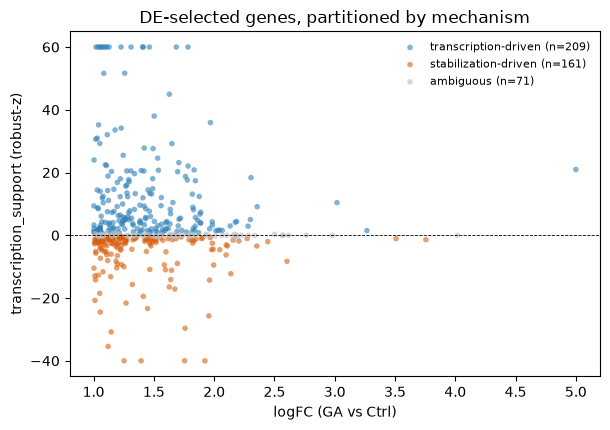

In [7]:
sel = res.selected.copy()
sup = pd.to_numeric(sel["transcription_support"], errors="coerce")
lfc = pd.to_numeric(sel["logFC"], errors="coerce")
cls = sel["mechanism_class"].astype(str)
colmap = {"transcription-driven": "#2c7fb8", "stabilization-driven": "#d95f0e",
          "ambiguous": "#bdbdbd"}
fig, ax = plt.subplots(figsize=(6.2, 4.4))
for k, col in colmap.items():
    m = cls == k
    ax.scatter(lfc[m], sup[m].clip(-40, 60), s=16, alpha=0.6, c=col,
               label=f"{k} (n={int(m.sum())})", edgecolors="none")
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_xlabel("logFC (GA vs Ctrl)"); ax.set_ylabel("transcription_support (robust-z)")
ax.set_title("DE-selected genes, partitioned by mechanism")
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

## Enrichment on the selected genes

In [8]:
enr = scat.run_enrichment(
    gene_list=res.selected.index.tolist(),
    gene_sets="GO_Biological_Process",
    organism="mouse", adata=adata, pval_cutoff=0.05,
)
print(f"GO BP terms (p.adjust < 0.05): {len(enr)}")
enr.sort_values("p.adjust").head(10)[["Term", "Overlap", "pvalue", "p.adjust"]]

GO BP terms (p.adjust < 0.05): 164


,Term,Overlap,pvalue,p.adjust
0,leukocyte mediated immunity (GO:0002443),39/407,2.297192e-14,1.603024e-10
1,leukocyte migration (GO:0050900),37/373,3.790104e-14,1.603024e-10
2,defense response to bacterium (GO:0042742),30/252,9.639352e-14,2.038482e-10
3,leukocyte chemotaxis (GO:0030595),28/216,7.766074e-14,2.038482e-10
4,cell chemotaxis (GO:0060326),31/294,9.885963e-13,1.672507e-09
5,neutrophil migration (GO:1990266),19/110,5.081006e-12,7.163372e-09
6,taxis (GO:0042330),36/421,7.102679e-12,7.510195e-09
7,chemotaxis (GO:0006935),36/420,6.629101e-12,7.510195e-09
8,neutrophil chemotaxis (GO:0030593),17/89,1.270982e-11,1.194582e-08
9,leukocyte mediated cytotoxicity (GO:0001909),20/143,7.618131e-11,6.444177e-08


## Takeaway

- with real replication, pseudobulk DE selects a program and scATrans partitions it
  into transcription- vs stabilization-driven — a soft per-gene annotation on top of
  a standard DE list;
- the DE step is pluggable (`de="wilcoxon"`, a PyDESeq2 kwargs dict, a precomputed
  edgeR/DESeq2 table, or a callable) — the partition is identical;
- for the **decisive program-level** mechanism call on curated pathways, see the
  {doc}`GSE226488 LPS notebook <t_gse226488_partition_mechanism>`.